# Jurkat Single-Cell Data Analysis
This notebook analyzes and visualizes the `jurkat.h5` dataset.

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Matplotlib is building the font cache; this may take a moment.
/var/folders/t1/md26m3vs5mldtk18qm327l6h0000gp/T/ipykernel_41510/173968578.py:10: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor='white')


## Load Data
Since the H5 file has a specific structure (X, obs, var), we can load it using `anndata`.

In [2]:
# The file is located at the project root, while the notebook is in 'zyt/'
h5_path = '../jurkat.h5'

def load_jurkat_h5(path):
    with h5py.File(path, 'r') as f:
        # Extract X
        X = f['X'][:]
        
        # Extract obs metadata
        obs_dict = {}
        for key in f['obs'].keys():
            if isinstance(f['obs'][key], h5py.Group):
                # Handle categorical data
                categories = f['obs'][key]['categories'][:].astype(str)
                codes = f['obs'][key]['codes'][:]
                obs_dict[key] = pd.Categorical.from_codes(codes, categories)
            else:
                data = f['obs'][key][:]
                if data.dtype == object:
                    data = data.astype(str)
                obs_dict[key] = data
        
        obs = pd.DataFrame(obs_dict)
        
        # Extract var metadata
        var_dict = {}
        for key in f['var'].keys():
            data = f['var'][key][:]
            if data.dtype == object:
                data = data.astype(str)
            var_dict[key] = data
        
        var = pd.DataFrame(var_dict)
        if '_index' in var.columns:
            var.index = var['_index']
            
        adata = ad.AnnData(X=X, obs=obs, var=var)
    return adata

adata = load_jurkat_h5(h5_path)
print(adata)

AnnData object with n_obs × n_vars = 21412 × 18080
    obs: 'UMI_count', 'batch_var', 'cell_barcode', 'cell_type', 'gem_group', 'gene', 'gene_id', 'gene_transcript', 'mitopercent', 'sgID_AB', 'target_gene', 'transcript', 'z_gemgroup_UMI'
    var: '_index'


/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [8]:
def print_h5_tree(path_or_file, group=None, prefix=""):
    if group is None:
        if isinstance(path_or_file, str):
            with h5py.File(path_or_file, 'r') as f:
                print(f"📦 {path_or_file}")
                print_h5_tree(path_or_file, group=f, prefix="")
        else:
            print(f"📦 {path_or_file.filename}")
            print_h5_tree(path_or_file, group=path_or_file, prefix="")
        return

    items = list(group.items())
    for i, (name, item) in enumerate(items):
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        
        if isinstance(item, h5py.Group):
            print(f"{prefix}{connector}📂 {name}/")
            new_prefix = prefix + ("    " if is_last else "│   ")
            print_h5_tree(path_or_file, group=item, prefix=new_prefix)
        else:
            info = f"(shape={item.shape}, dtype={item.dtype})"
            print(f"{prefix}{connector}📄 {name:20} {info}")

print_h5_tree(h5_path)

📦 ../jurkat.h5
├── 📄 X                    (shape=(21412, 18080), dtype=float32)
├── 📂 layers/
├── 📂 obs/
│   ├── 📄 UMI_count            (shape=(21412,), dtype=float32)
│   ├── 📂 batch_var/
│   │   ├── 📄 categories           (shape=(55,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📄 cell_barcode         (shape=(21412,), dtype=object)
│   ├── 📂 cell_type/
│   │   ├── 📄 categories           (shape=(1,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📄 gem_group            (shape=(21412,), dtype=int64)
│   ├── 📂 gene/
│   │   ├── 📄 categories           (shape=(69,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📂 gene_id/
│   │   ├── 📄 categories           (shape=(69,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📂 gene_transcript/
│   │   ├── 📄 categories           (shape=(201,), dtype=object)
│   │   └── 📄 codes               

## Quality Control
Visualize basic QC metrics like UMI counts and mitochondrial percentage.

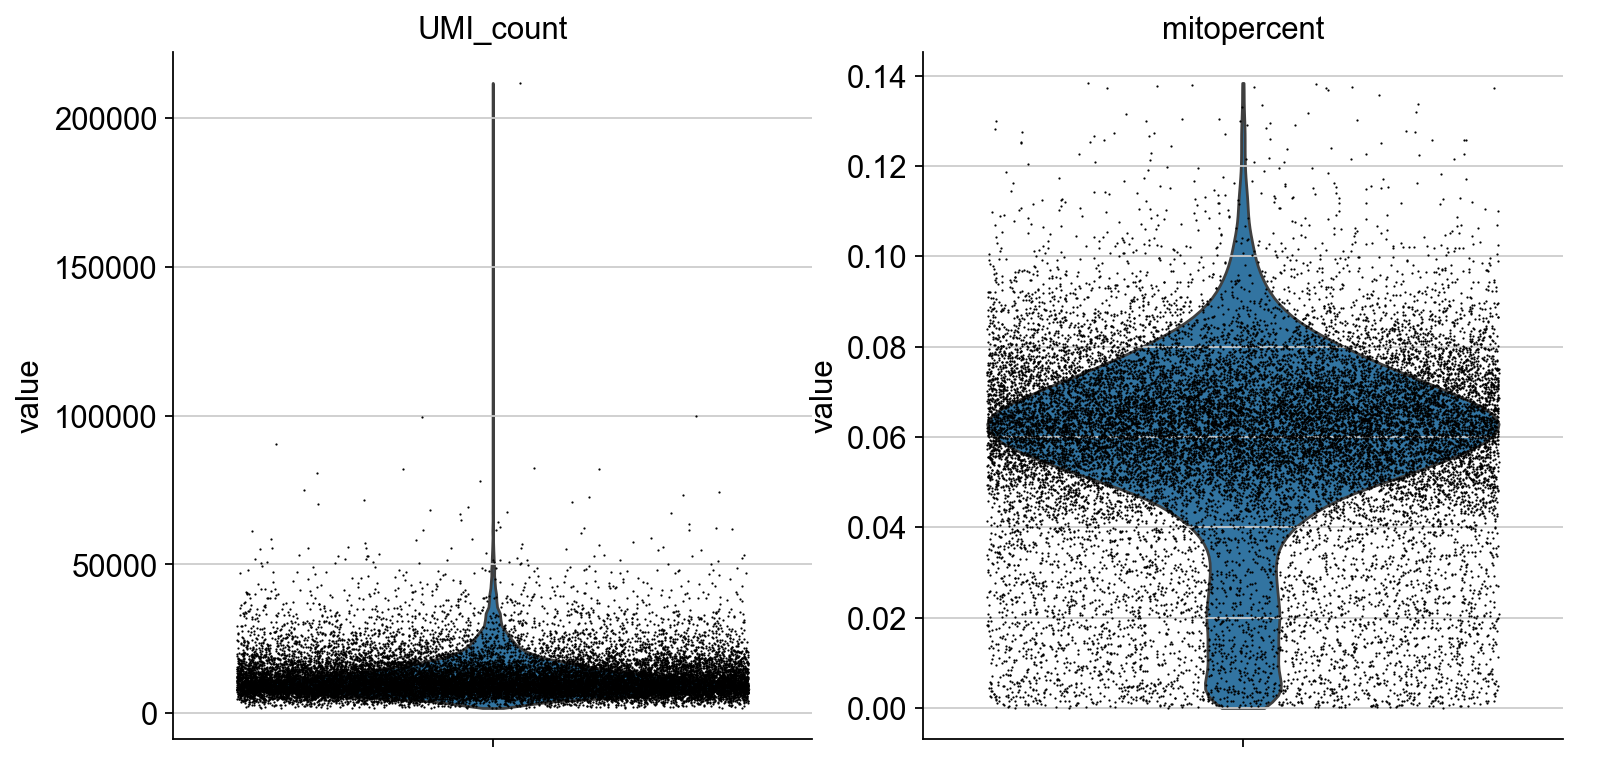

In [3]:
sc.pl.violin(adata, ['UMI_count', 'mitopercent'], jitter=0.4, multi_panel=True)

## Preprocessing
Normalization and Log-transformation.

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

normalizing counts per cell
    finished (0:00:00)


## Dimensionality Reduction and Clustering

extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


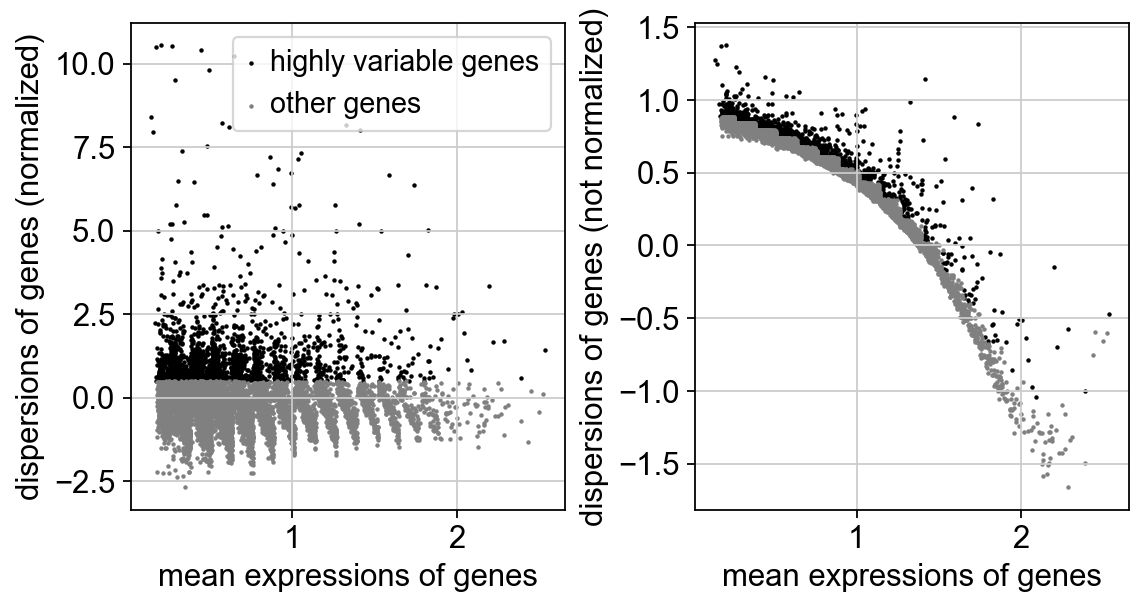

/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:05)
computing neighbors
    using 'X_pca' with n_pcs = 40


/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:16)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)


In [5]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

## Visualizing Results

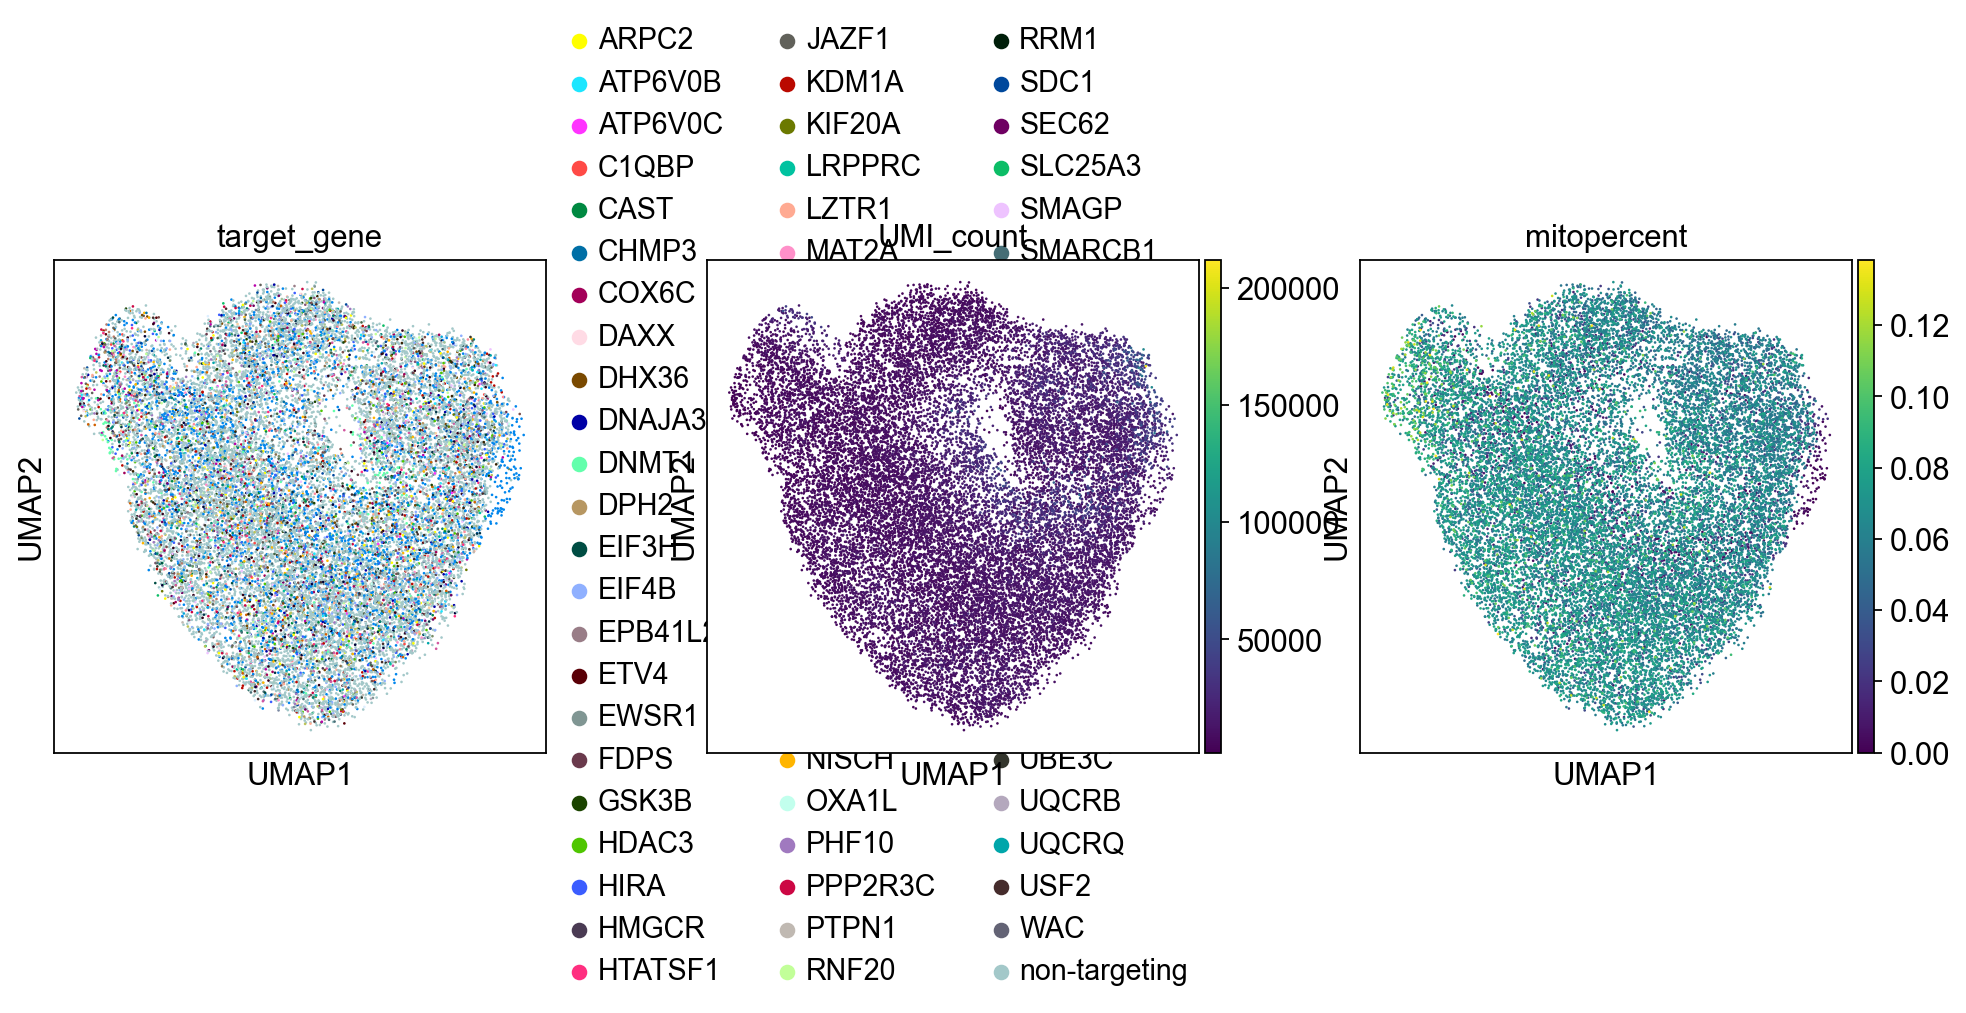

In [6]:
sc.pl.umap(adata, color=['target_gene', 'UMI_count', 'mitopercent'])